In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [4]:
df = df.dropna(subset=['Year'])
df['Publisher'] = df['Publisher'].fillna("Unknown")
df['Year'] = df['Year'].astype(int)

In [5]:
genre_top10 = df.groupby("Genre")["Global_Sales"].sum() \
                .sort_values(ascending=False).head(10)
print(genre_top10)

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Name: Global_Sales, dtype: float64


In [6]:
platform_top10 = df.groupby("Platform")["Global_Sales"].sum() \
                   .sort_values(ascending=False).head(10)
print(platform_top10)

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
Name: Global_Sales, dtype: float64


In [7]:
publisher_top10 = df.groupby("Publisher")["Global_Sales"].sum() \
                    .sort_values(ascending=False).head(10)
print(publisher_top10)

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64


In [9]:
region_sales = df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales","Global_Sales"]].sum()
region_percent = region_sales.div(region_sales["Global_Sales"], axis=0) * 100
region_percent[["NA_Sales","EU_Sales","JP_Sales"]].head()

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,50.020895,29.977712,9.208999
Adventure,43.466780,27.167802,22.150767
Fighting,49.710618,22.519986,19.626168
Misc,50.460119,26.807252,13.373536
Platform,53.788820,24.201894,15.757101


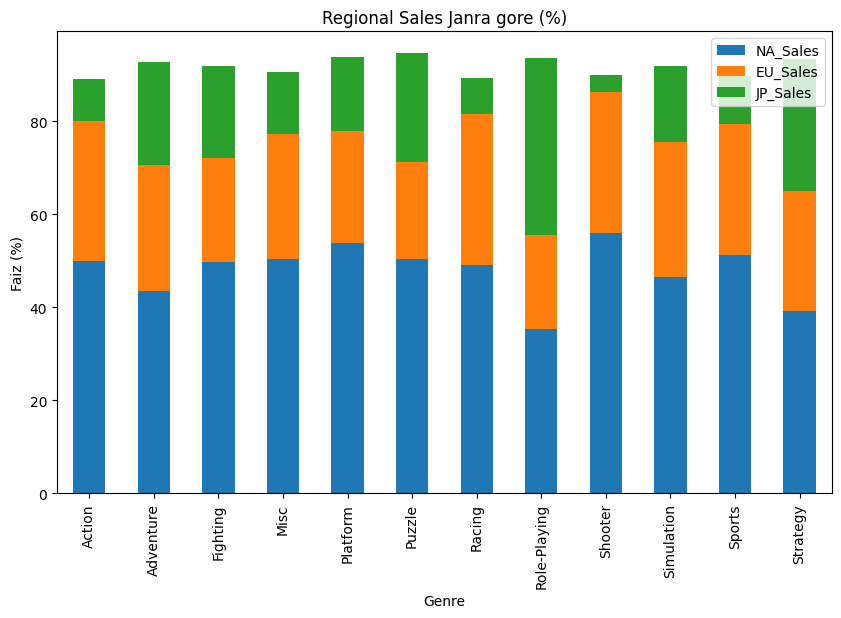

In [12]:
region_percent[["NA_Sales","EU_Sales","JP_Sales"]].plot(
    kind="bar", stacked=True, figsize=(10,6))
plt.title("Regional Sales Janra gore (%)")
plt.ylabel("Faiz (%)")
plt.show()

In [ ]:
print("NA top genre:", df.groupby("Genre")["NA_Sales"].sum().idxmax())
print("EU top genre:", df.groupby("Genre")["EU_Sales"].sum().idxmax())
print("JP top genre:", df.groupby("Genre")["JP_Sales"].sum().idxmax())

NA top genre: Action
EU top genre: Action
JP top genre: Role-Playing


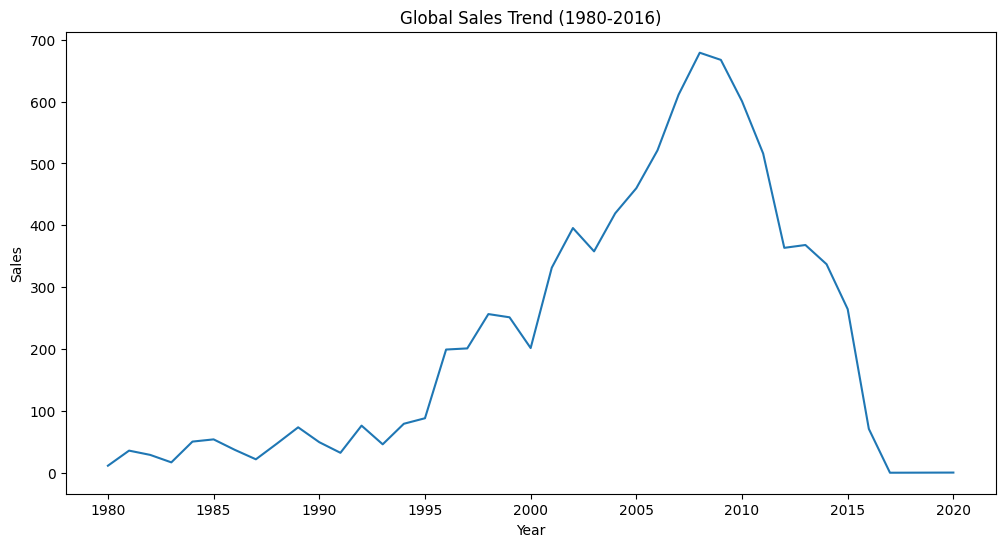

In [14]:
yearly_sales = df.groupby("Year")["Global_Sales"].sum()
plt.figure(figsize=(12,6))
plt.plot(yearly_sales)
plt.title("Global Sales Trend (1980-2016)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [15]:
top_games = df.sort_values(by="Global_Sales", ascending=False).head(10)
top_games[["Name","Platform","Genre","Global_Sales"]]

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,Tetris,GB,Puzzle,30.26
6,New Super Mario Bros.,DS,Platform,30.01
7,Wii Play,Wii,Misc,29.02
8,New Super Mario Bros. Wii,Wii,Platform,28.62
9,Duck Hunt,NES,Shooter,28.31


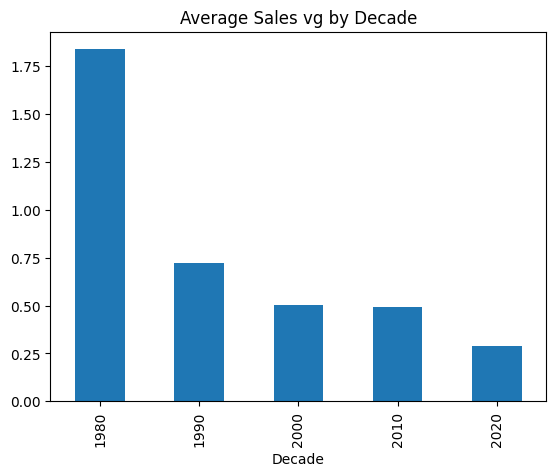

In [18]:
df["Decade"] = (df["Year"] // 10) * 10
decade_sales = df.groupby("Decade")["Global_Sales"].mean()
decade_sales.plot(kind="bar")
plt.title("Average Sales vg by Decade")
plt.show() #bonus 

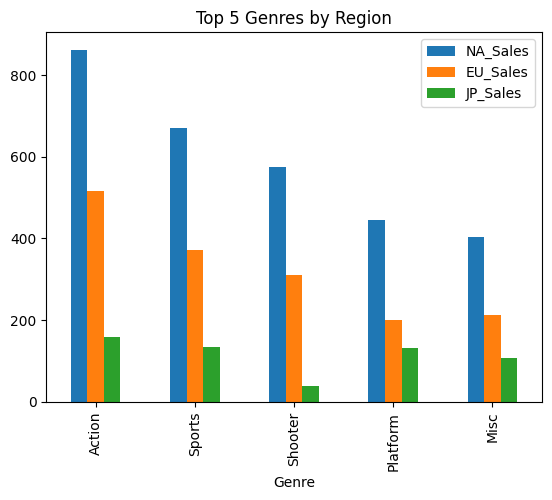

In [21]:
top5 = df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales"]].sum().nlargest(5, "NA_Sales")
top5.plot(kind="bar")
plt.title("Top 5 Genres by Region")
plt.show()